In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import rpy2.robjects as ro
import os
from rpy2.robjects import pandas2ri
import gzip
from scipy.stats import spearmanr, pearsonr
readRDS = ro.r['readRDS']
    

During startup - Warning messages:
1: Setting LC_CTYPE failed, using "C" 
2: Setting LC_COLLATE failed, using "C" 
3: Setting LC_TIME failed, using "C" 
4: Setting LC_MESSAGES failed, using "C" 
5: Setting LC_MONETARY failed, using "C" 
6: Setting LC_PAPER failed, using "C" 
7: Setting LC_MEASUREMENT failed, using "C" 


In [2]:
rds = readRDS(f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/Ru_plots/leafcutter2_fig4e_right.tspan14.25Mar.rds')
    

In [3]:
with (ro.default_converter + pandas2ri.converter).context():
    df = ro.conversion.get_conversion().rpy2py(rds)


In [13]:
df['variable'] = list(df.variable)

In [29]:
232/2

116.0

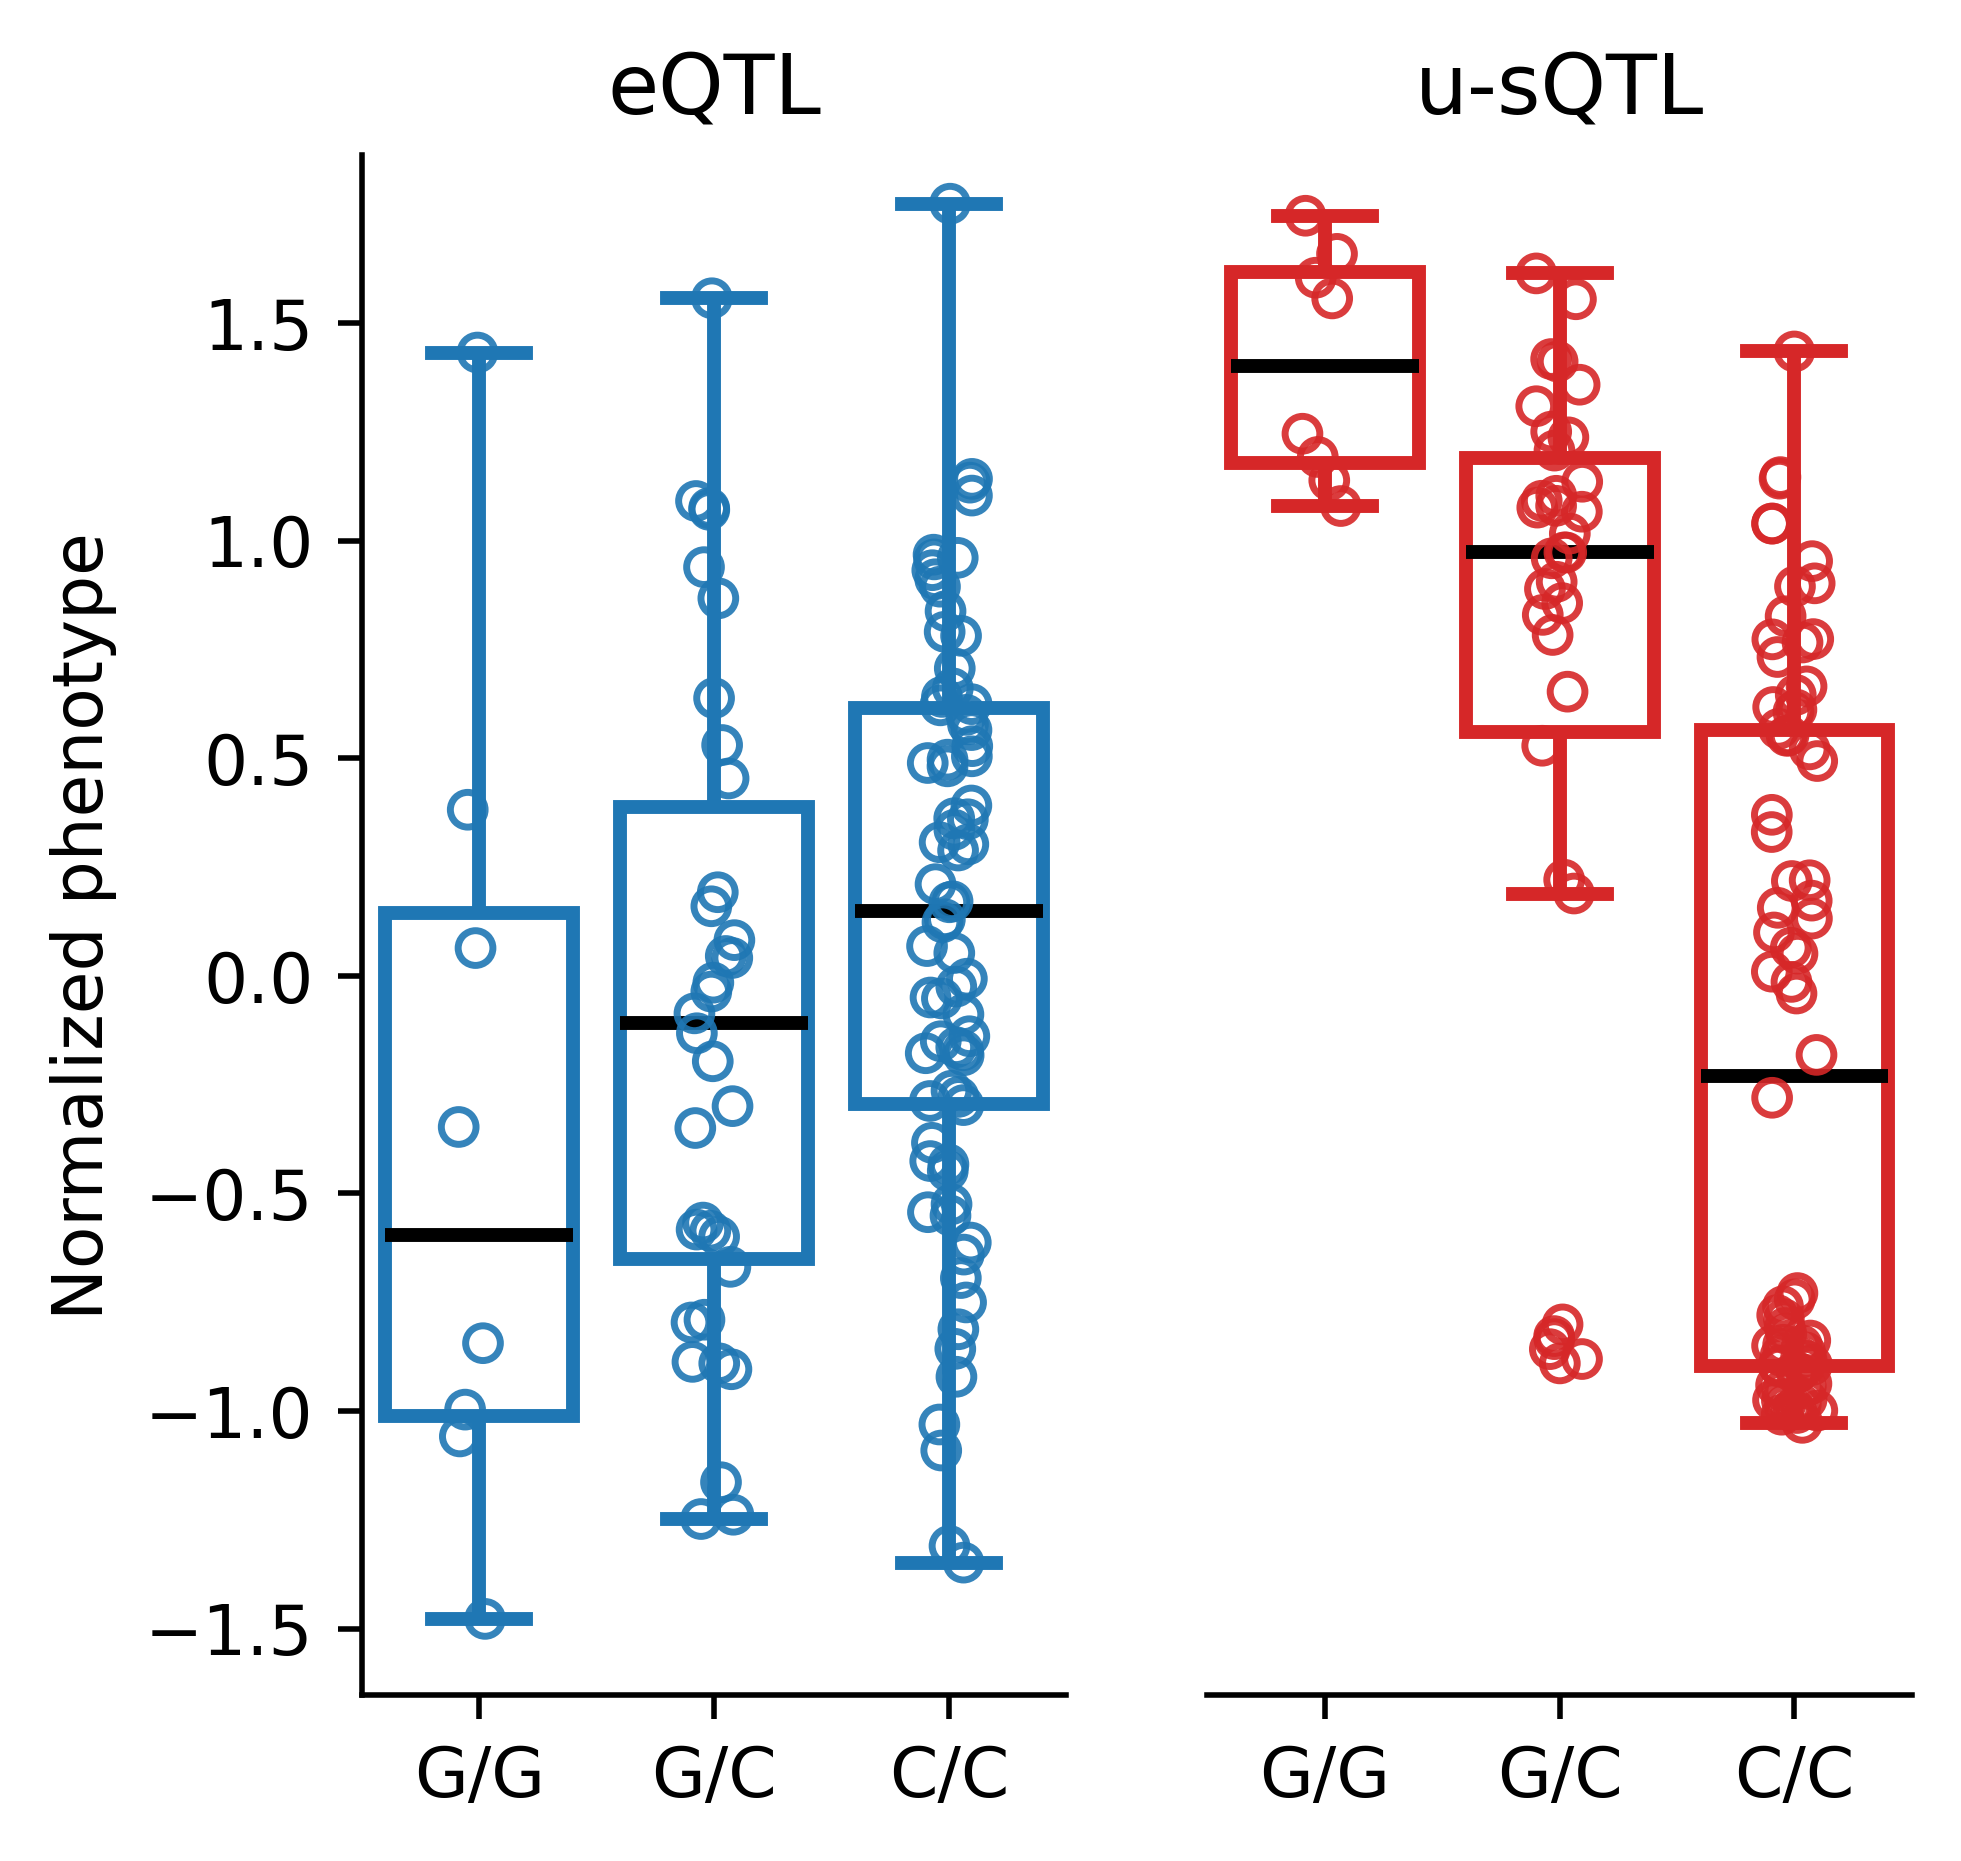

In [4]:
from scipy.stats import t

fig, axes = plt.subplots(ncols=2, figsize=(4, 4), width_ratios=[1, 1], dpi=500)

sns.boxplot(data=df.loc[df.variable=='eQTL'], x = 'geno', y='value', ax=axes[0],
            boxprops=dict(facecolor='white', edgecolor='tab:blue'), showfliers=False,
            whiskerprops = dict(color='tab:blue'),
           capprops = dict(color='tab:blue'),
           medianprops = dict(linewidth=2, color='black'), linewidth=2)

sns.stripplot(data=df.loc[df.variable=='eQTL'], x = 'geno', y='value', alpha=0.9, 
              edgecolor='tab:blue', facecolor='none', linewidth=1, ax=axes[0], rasterized=True)





sns.boxplot(data=df.loc[df.variable=='u-sQTL'], x = 'geno', y='value', ax=axes[1],
            boxprops=dict(facecolor='white', edgecolor='tab:red'), showfliers=False,
            whiskerprops = dict(color='tab:red'),
           capprops = dict(color='tab:red'),
           medianprops = dict(linewidth=2, color='black'), linewidth=2)

sns.stripplot(data=df.loc[df.variable=='u-sQTL'], x = 'geno', y='value', alpha=0.9, 
              edgecolor='tab:red', facecolor='none', linewidth=1, ax=axes[1], rasterized=True)


axes[0].spines[['top', 'right']].set_visible(False)
axes[1].spines[['left', 'top', 'right']].set_visible(False)
axes[1].set_yticks([])
axes[1].set_ylabel('')

ax0y = axes[0].get_ylim()
ax1y = axes[1].get_ylim()

ybottom = np.min([ax0y[0], ax1y[0]])
ytop = np.min([ax0y[1], ax1y[1]])

ylim = (ybottom, ytop)
axes[0].set_ylim(ylim)
axes[1].set_ylim(ylim)

axes[0].set_title('eQTL')
axes[1].set_title('u-sQTL')

axes[0].set_ylabel('Normalized phenotype')
axes[0].set_xlabel('')
axes[1].set_xlabel('')



plt.savefig('../code/plots/Fig5/Fig5D.png', dpi=500, bbox_inches='tight')
plt.savefig('../code/plots/Fig5/Fig5D.pdf', dpi=500, bbox_inches='tight')
plt.savefig('../code/plots/Fig5/Fig5D.svg', dpi=500, bbox_inches='tight')

In [36]:
axes[1].get_ylim()

(np.float64(-1.1658796500000002), np.float64(1.88483065))

In [37]:
axes[0].get_ylim()

(np.float64(-1.6534088500000002), np.float64(2.21255985))

In [ ]:
def make_boxplot_df(qqnorm_data, phenotype, record, phenotype_class='', color_by_phenotype=False):
    try:
        qqnorm_data = qqnorm_data.set_index('pid')
    except:
        print('nothing')
    qq_samples = qqnorm_data.columns[6:]
    hom_refs = [str(x.sample) for x in record.get_hom_refs() if str(x.sample) in qq_samples]
    hets = [str(x.sample) for x in record.get_hets() if str(x.sample) in qq_samples]
    hom_alts = [str(x.sample) for x in record.get_hom_alts() if str(x.sample) in qq_samples]
    
    samples = hom_refs + hets + hom_alts
    
    ref = record.REF
    alt = record.ALT[0]
    
    genotype = [str(ref) + ',' + str(ref)]*len(hom_refs)
    genotype += [str(ref) + ',' + str(alt)]*len(hets)
    genotype += [str(alt) + ',' + str(alt)]*len(hom_alts)
    
    df = pd.DataFrame()
    df['genotype'] = genotype
    df['qqnorm'] = list(qqnorm_data.loc[phenotype, samples].astype(float))
    df.index = hom_refs + hets + hom_alts

    # return df
    
    if color_by_phenotype:
        colores = [color_by_phenotype]*3

    else:
        colores = ['red', 'purple', 'blue']#ColorPallette#list(plt.get_cmap('tab10').colors)
    
    
    
    # plt.figure(figsize=(2.5, 2.5))
    fig, ax = plt.subplots(figsize=(2.5, 2.5), dpi=300)
    
    sns.boxplot(x = 'genotype', y = 'qqnorm', data = df, width=.5, fliersize=0, 
                     linewidth=2,  boxprops=dict(facecolor='white', edgecolor='black'), ax=ax)#, palette=colorbrewer)

    

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.tick_params(size=4, width=2, labelsize=14)
    # sns.despine(offset=5, trim=True)
    sns.stripplot(x = 'genotype', y = 'qqnorm', data = df, alpha=0.5, edgecolor='tab:gray', facecolor='none', linewidth=1, ax=ax, rasterized=True)
    # ax.set_yticks([-1, 0, 1])
    # plt.title(phenotype_class + ': ' +phenotype, size=14)
    return ax
